In [8]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pickle
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
from prophet import Prophet
from src.data_loader import load_data

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
df = load_data()

df["duration_min"] = (df["ended_at"] - df["started_at"]).dt.total_seconds() / 60
df = df[df["duration_min"] <= 180].copy()
df["hour"] = df["started_at"].dt.hour
print(df.shape)

Found 31 parquet file(s). Loading...
Loaded 28,206,527 records.
(28165708, 15)


In [4]:
top_start = (
    df.groupby("start_station_name")
    .size()
    .reset_index(name="departures")
    .sort_values("departures", ascending=False)
)

print("Top 10 departure stations:")
print(top_start.head(10).to_string(index=False))

Top 10 departure stations:
      start_station_name  departures
         W 21 St & 6 Ave       97197
   West St & Chambers St       95008
Pier 61 at Chelsea Piers       93454
   Lafayette St & E 8 St       87364
         9 Ave & W 33 St       80404
      Broadway & W 58 St       80289
         W 31 St & 7 Ave       80082
        11 Ave & W 41 St       79974
      Broadway & E 14 St       79033
 University Pl & E 14 St       78158


In [5]:
print(f"Unique start stations: {df['start_station_name'].nunique():,}")
print(f"Unique end stations:   {df['end_station_name'].nunique():,}")

Unique start stations: 2,180
Unique end stations:   2,261


In [6]:
departures = df.groupby("start_station_name").size().rename("departures")
arrivals   = df.groupby("end_station_name").size().rename("arrivals")

net_flow = pd.concat([departures, arrivals], axis=1).fillna(0)
net_flow["net"] = net_flow["arrivals"] - net_flow["departures"]
net_flow = net_flow.sort_values("net")

print("Top 10 net outflow stations (bikes leaving):")
print(net_flow.head(10))

print("\nTop 10 net inflow stations (bikes arriving):")
print(net_flow.tail(10))

Top 10 net outflow stations (bikes leaving):
                                         departures  arrivals     net
Broadway & W 61 St                          47403.0     44992 -2411.0
W 54 St & 9 Ave                             42284.0     39885 -2399.0
Broadway & W 56 St                          28878.0     26507 -2371.0
W 49 St & 8 Ave                             28285.0     26126 -2159.0
E 39 St & Lexington Ave                     47495.0     45506 -1989.0
Plaza St East & Flatbush Ave                33834.0     31894 -1940.0
Eastern Pkwy & Kingston Ave                 18277.0     16487 -1790.0
E 35 St & Madison Ave                       27114.0     25374 -1740.0
E 63 St & 3 Ave                             27930.0     26209 -1721.0
Eastern Pkwy & Franklin Ave (NE Corner)     21989.0     20278 -1711.0

Top 10 net inflow stations (bikes arriving):
                             departures  arrivals     net
Hudson Blvd W & W 36 St         22219.0     23069   850.0
48 Ave & 5 St          

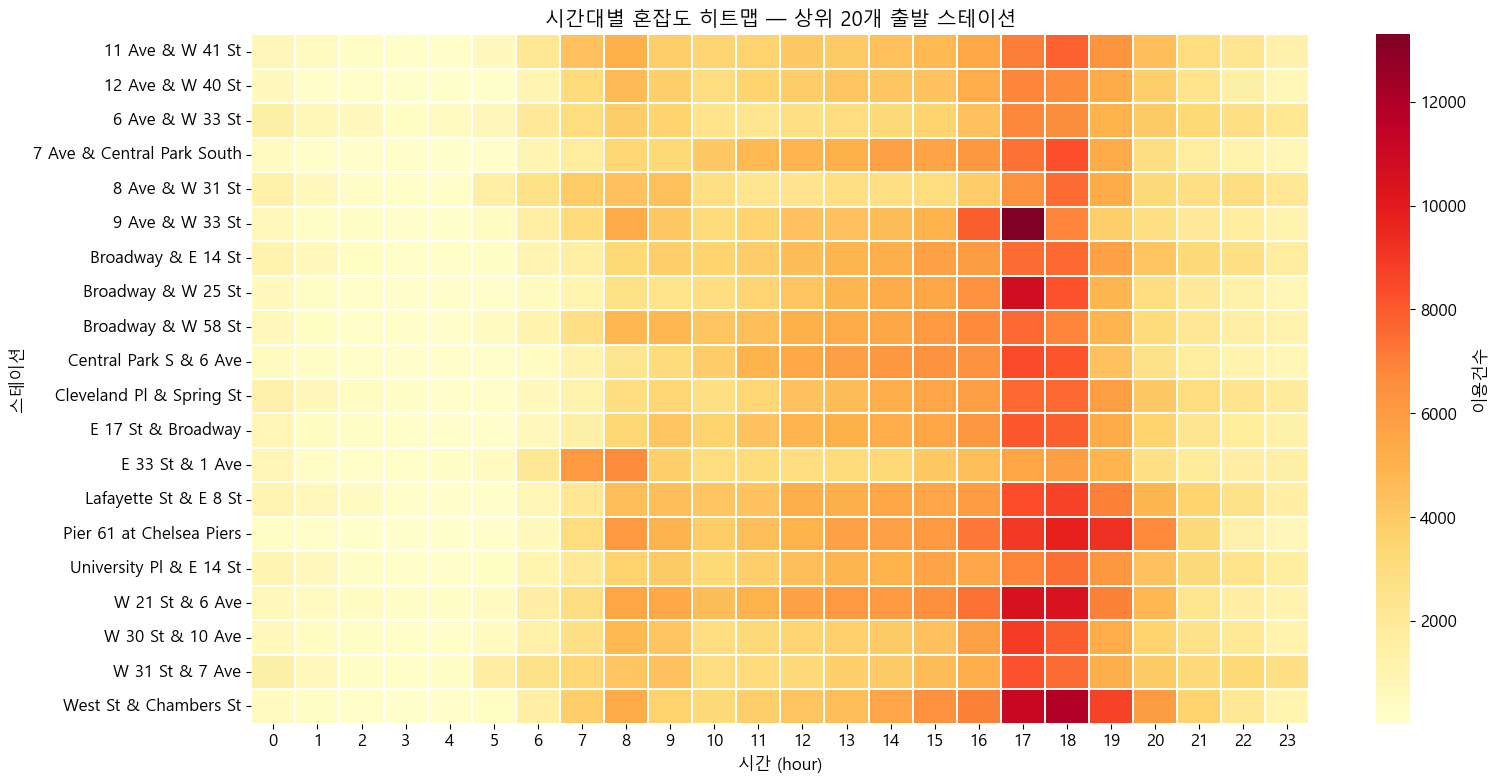

In [12]:
top20_stations = top_start.head(20)["start_station_name"].tolist()

heatmap_data = (
    df[df["start_station_name"].isin(top20_stations)]
    .groupby(["start_station_name", "hour"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(16, 8))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "이용건수"}
)
plt.title('시간대별 혼잡도 히트맵 — 상위 20개 출발 스테이션')
plt.xlabel('시간 (hour)')
plt.ylabel('스테이션')
plt.tight_layout()
plt.show()

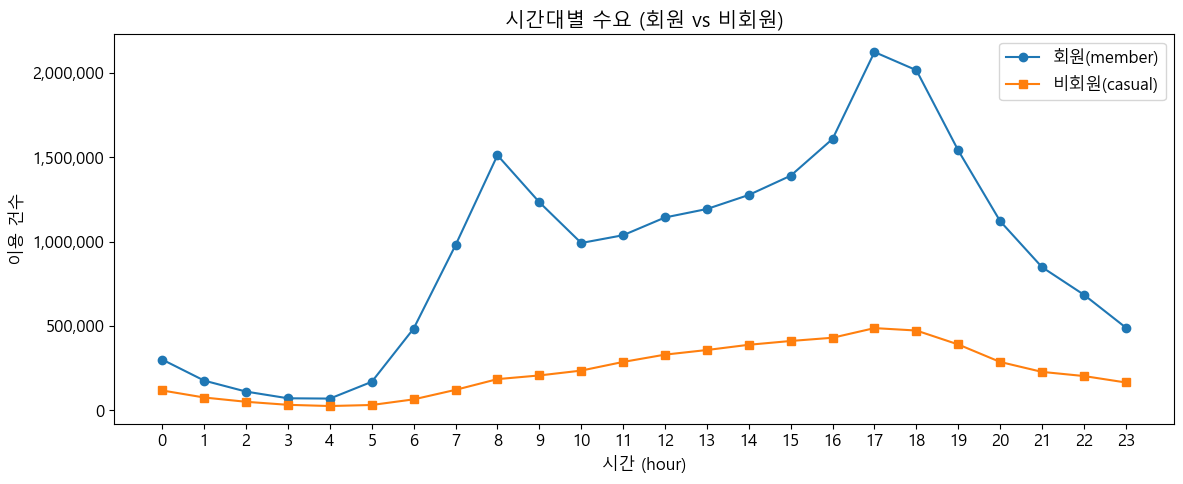

In [15]:
# 시간대별 수요 (회원 vs 비회원)
hourly_user = (
    df.groupby(['hour', 'member_casual'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.plot(hourly_user['hour'], hourly_user['member'], marker='o', label='회원(member)')
plt.plot(hourly_user['hour'], hourly_user['casual'], marker='s', label='비회원(casual)')
plt.title('시간대별 수요 (회원 vs 비회원)')
plt.xlabel('시간 (hour)')
plt.ylabel('이용 건수')
plt.xticks(range(0, 24))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
plt.legend()
plt.tight_layout()
plt.show()

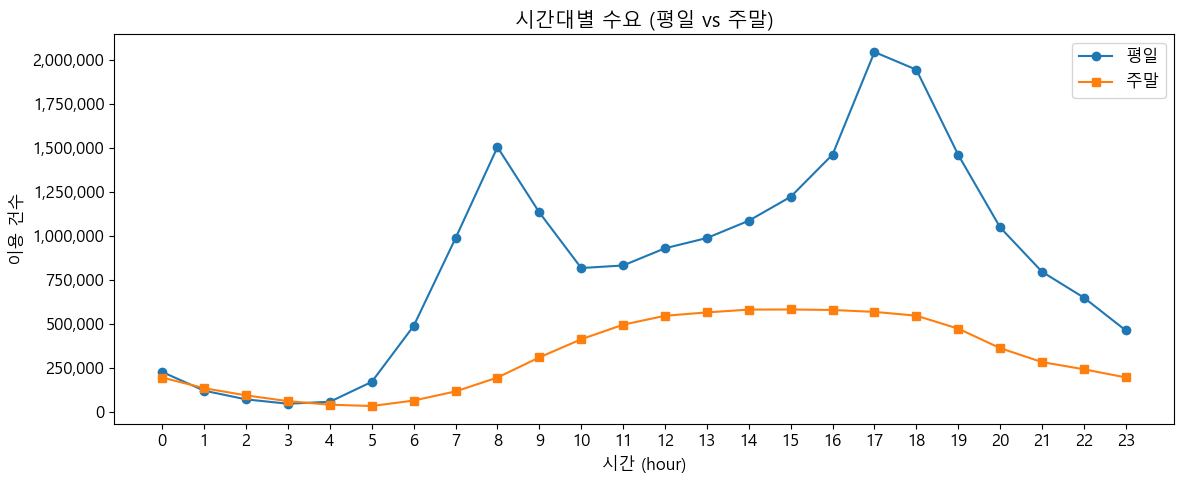

In [16]:
# 시간대별 수요 (평일 vs 주말)
df['is_weekend'] = df['started_at'].dt.dayofweek.isin([5, 6])

hourly_week = (
    df.groupby(['hour', 'is_weekend'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={False: '평일', True: '주말'})
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.plot(hourly_week['hour'], hourly_week['평일'], marker='o', label='평일')
plt.plot(hourly_week['hour'], hourly_week['주말'], marker='s', label='주말')
plt.title('시간대별 수요 (평일 vs 주말)')
plt.xlabel('시간 (hour)')
plt.ylabel('이용 건수')
plt.xticks(range(0, 24))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
plt.legend()
plt.tight_layout()
plt.show()

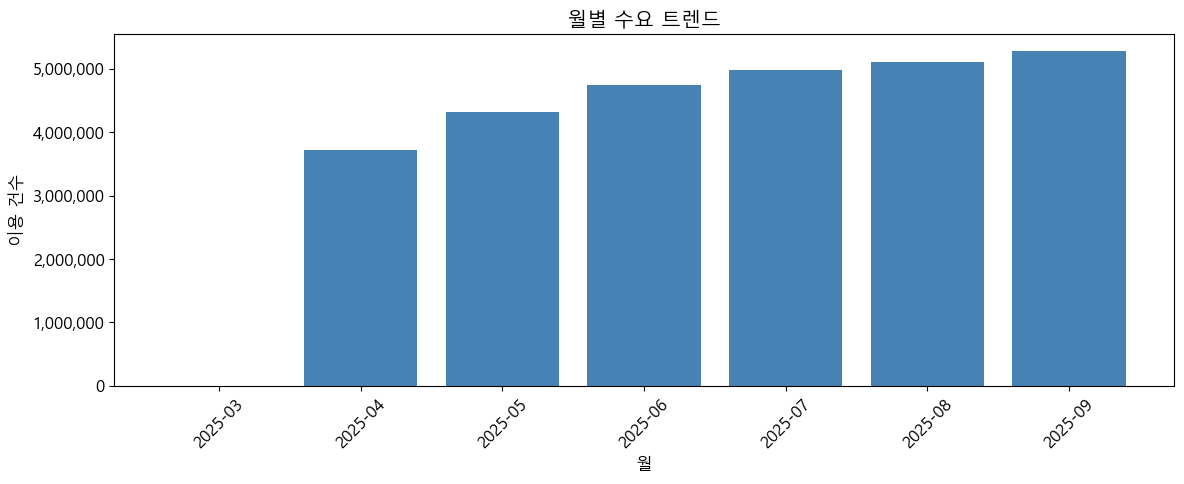

In [17]:
# 월별 수요 트렌드
df['month'] = df['started_at'].dt.to_period('M')

monthly = (
    df.groupby('month')
    .size()
    .reset_index(name='ride_count')
)
monthly['month_str'] = monthly['month'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly['month_str'], monthly['ride_count'], color='steelblue')
ax.set_title('월별 수요 트렌드')
ax.set_xlabel('월')
ax.set_ylabel('이용 건수')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()